<a href="https://colab.research.google.com/github/subhrajit77/Palm-Plant-Disease-detection-using-ML-DL/blob/main/palm2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# General
import os
import shutil
import random
import numpy as np

# Image processing
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# Model building
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# For splitting data
from sklearn.model_selection import train_test_split

In [ ]:

raw_data_path = '/content/drive/MyDrive/Raw Data'

# Processed data folder
processed_data_path = '/content/drive/MyDrive/Final_Data2'

# Folders for train, val, test
train_dir = os.path.join(processed_data_path, 'train')
val_dir = os.path.join(processed_data_path, 'val')
test_dir = os.path.join(processed_data_path, 'test')

# Classes
classes = ['Healthy', 'Stage1', 'Stage2', 'Stage3']

# Create folders
for dir_path in [train_dir, val_dir, test_dir]:
    for class_name in classes:
        os.makedirs(os.path.join(dir_path, class_name), exist_ok=True)


In [ ]:
def split_data(class_folder, train_ratio=0.7, val_ratio=0.1, test_ratio=0.2):
    images = os.listdir(os.path.join(raw_data_path, class_folder))
    random.shuffle(images)

    total_images = len(images)
    train_count = int(total_images * train_ratio)
    val_count = int(total_images * val_ratio)

    train_images = images[:train_count]
    val_images = images[train_count:train_count+val_count]
    test_images = images[train_count+val_count:]

    for image in train_images:
        shutil.copy(os.path.join(raw_data_path, class_folder, image),
                    os.path.join(train_dir, class_folder, image))

    for image in val_images:
        shutil.copy(os.path.join(raw_data_path, class_folder, image),
                    os.path.join(val_dir, class_folder, image))

    for image in test_images:
        shutil.copy(os.path.join(raw_data_path, class_folder, image),
                    os.path.join(test_dir, class_folder, image))

# Apply splitting for all classes
for class_name in classes:
    split_data(class_name)


KeyboardInterrupt: 

In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# Define paths
base_dir = '/content/drive/MyDrive/Final_Data2'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Image settings
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Simple preprocessing without augmentation
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Generators
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 1510 images belonging to 4 classes.
Found 215 images belonging to 4 classes.
Found 436 images belonging to 4 classes.


In [ ]:
import os
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# Define augmentation generator
augmentor = ImageDataGenerator(
    rotation_range=20,              # rotate up to 20 degrees
    width_shift_range=0.1,           # shift horizontally up to 10%
    height_shift_range=0.1,          # shift vertically up to 10%
    zoom_range=0.2,                  # zoom in/out by 20%
    shear_range=0.1,                 # shear transformation
    horizontal_flip=True,            # horizontal flip
    fill_mode='nearest',             # fill missing pixels after transformation
    brightness_range=[0.7, 1.3],     # vary brightness between 70% (darker) and 130% (brighter)
    channel_shift_range=30.0         # random shift in the RGB color channels to simulate contrast variations
)

# Paths
train_dir = '/content/drive/MyDrive/Final_Data2/train'
classes = ['Healthy', 'Stage1', 'Stage2', 'Stage3']

# Augment training images
def augment_class_images(class_folder, augment_times=3):  # 3 augmented per image
    class_path = os.path.join(train_dir, class_folder)
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for img_name in tqdm(images, desc=f'Augmenting {class_folder}'):
        img_path = os.path.join(class_path, img_name)
        img = load_img(img_path)
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)

        base_name = os.path.splitext(img_name)[0]

        i = 0
        for batch in augmentor.flow(x, batch_size=1):
            i += 1
            aug_img_name = f'{base_name}_aug{i}.jpg'
            save_path = os.path.join(class_path, aug_img_name)
            save_img(save_path, batch[0].astype('uint8'))
            if i >= augment_times:
                break

# augmentation for all classes
for class_name in classes:
    augment_class_images(class_name)


Augmenting Stage3: 100%|██████████| 200/200 [00:17<00:00, 11.25it/s]


In [ ]:


import os

train_dir = '/content/drive/MyDrive/Final_Data/train'
image_extensions = ('.jpg', '.jpeg', '.png')  # Add other extensions if needed

total_images = 0
for class_folder in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_folder)
    if os.path.isdir(class_path):  # Ensure it's a directory, not a file
        for filename in os.listdir(class_path):
            if filename.lower().endswith(image_extensions):
                total_images += 1
print(f"Total number of images in the 'train' folder: {total_images}")


Total number of images in the 'train' folder: 6040


In [ ]:

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers on top
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(len(classes), activation='softmax')(x)

# Full model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


NameError: name 'classes' is not defined

In [ ]:
# Callbacks
# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# checkpoint = ModelCheckpoint('vgg16_best_model.h5', monitor='val_accuracy', save_best_only=True)

# Train
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=150
    # callbacks=[early_stop, checkpoint]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 36s 460ms/step - accuracy: 0.6631 - loss: 3.5912 - val_accuracy: 0.9767 - val_loss: 0.0828
Epoch 2/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step - accuracy: 0.9768 - loss: 0.0618 - val_accuracy: 0.9953 - val_loss: 0.0203
Epoch 3/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 214ms/step - accuracy: 0.9843 - loss: 0.0769 - val_accuracy: 0.9953 - val_loss: 0.0091
Epoch 4/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.9938 - loss: 0.0255 - val_accuracy: 1.0000 - val_loss: 0.0054
Epoch 5/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step - accuracy: 0.9916 - loss: 0.0370 - val_accuracy: 1.0000 - val_loss: 0.0043
Epoch 6/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 218ms/step - accuracy: 0.9938 - loss: 0.0118 - val_accuracy: 1.0000 - val_loss: 0.0046
Epoch 7/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - accuracy: 0.9905 - loss: 0.0135 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 8/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 188ms/step - accuracy: 0.9989 - loss: 0.0101 - va

In [ ]:

model_save_path = '/content/drive/MyDrive/Saved Models/palm_saved_2.h5'


import os
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

model.save(model_save_path)
print(f"Model saved successfully to {model_save_path}")

Model saved successfully to /content/drive/MyDrive/Saved Models/palm_saved_2.h5


In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 710ms/step - accuracy: 0.9910 - loss: 0.1149
Test Accuracy: 99.31%


14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 495ms/step


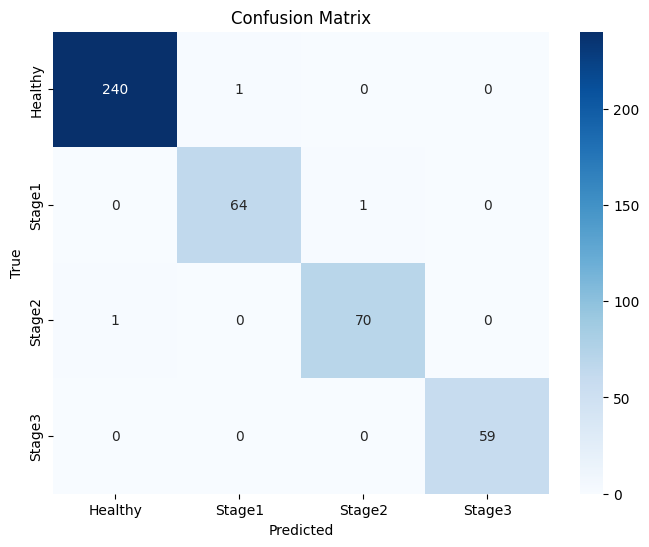


Classification Report:

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       241
      Stage1       0.98      0.98      0.98        65
      Stage2       0.99      0.99      0.99        71
      Stage3       1.00      1.00      1.00        59

    accuracy                           0.99       436
   macro avg       0.99      0.99      0.99       436
weighted avg       0.99      0.99      0.99       436



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report



Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)


y_true = test_generator.classes


class_labels = list(test_generator.class_indices.keys())

# 2. Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


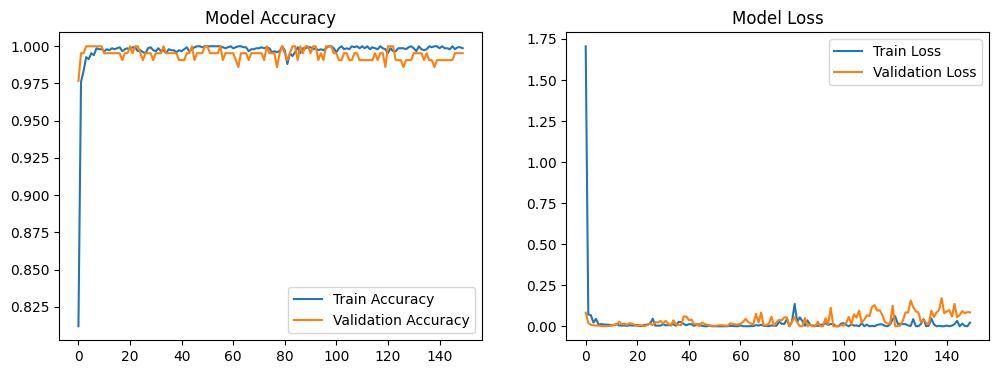

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

In [ ]:
# Final Training & Validation Accuracy
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc * 100:.2f}%")

# Test Accuracy
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Final Training Accuracy: 99.87%
Final Validation Accuracy: 99.53%
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 222ms/step - accuracy: 0.9910 - loss: 0.1149
Test Accuracy: 99.31%


In [ ]:

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

def predict_on_image(image_path, model):
    img = image.load_img(image_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    preds = model.predict(x)
    class_idx = np.argmax(preds[0])
    class_labels = list(test_generator.class_indices.keys())

    predicted_class = class_labels[class_idx]
    confidence = preds[0][class_idx]

    print(f"Predicted class: {predicted_class}")
    print(f"Confidence: {confidence:.2f}")

    return predicted_class, confidence

# # Load  trained model
# from tensorflow.keras.models import load_model
# model = load_model('wsd_detection_model.h5')


image_path = '/content/drive/MyDrive/Final_Data2/test/Stage1/wsphase1-473.jpg'
predicted_class, confidence = predict_on_image(image_path, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class: Stage1
Confidence: 1.00


Train for 180 epochs


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model('/content/drive/MyDrive/Saved Models/palm_saved_2.h5')

In [ ]:
# General
import os
import shutil
import random
import numpy as np

# Image processing
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# Model building
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# For splitting data
from sklearn.model_selection import train_test_split

In [ ]:
# Classes
classes = ['Healthy', 'Stage1', 'Stage2', 'Stage3']

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# Define paths
base_dir = '/content/drive/MyDrive/Final_Data2'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Image settings
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Simple preprocessing without augmentation
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Generators
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)



Found 6040 images belonging to 4 classes.
Found 215 images belonging to 4 classes.
Found 436 images belonging to 4 classes.


In [ ]:

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers on top
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(len(classes), activation='softmax')(x)

# Full model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,500 (80.64 MB)

 Trainable params: 6,423,812 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

XAI

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/Saved Models/palm_saved_2.h5')

In [ ]:
!pip install tf-keras-vis --quiet

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.1 MB/s eta 0:00:00


In [ ]:
img_path = '/content/drive/MyDrive/Final_Data2/test/Stage1/wsphase1-473.jpg'  # Change path accordingly

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # Normalize
img_input = np.expand_dims(img_array, axis=0)

In [ ]:
score = CategoricalScore([np.argmax(model.predict(img_input))])
modifier = ReplaceToLinear()

gradcam = GradcamPlusPlus(model,
                          model_modifier=modifier,
                          clone=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [ ]:
cam = gradcam(score,
              img_input,
              penultimate_layer=-1)  # -1 means the last conv layer

# Postprocess
heatmap = cam[0]


In [ ]:
from PIL import Image
import cv2

def overlay_heatmap(img_array, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    # Convert heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)

    # Apply colormap (e.g., JET)
    heatmap_color = cv2.applyColorMap(heatmap, colormap)

    # Resize heatmap to image size
    heatmap_color = cv2.resize(heatmap_color, (img_array.shape[1], img_array.shape[0]))

    # Convert original image to uint8
    original_image = np.uint8(255 * img_array)

    # Overlay heatmap on original image
    overlayed = cv2.addWeighted(original_image, 1 - alpha, heatmap_color, alpha, 0)

    return overlayed


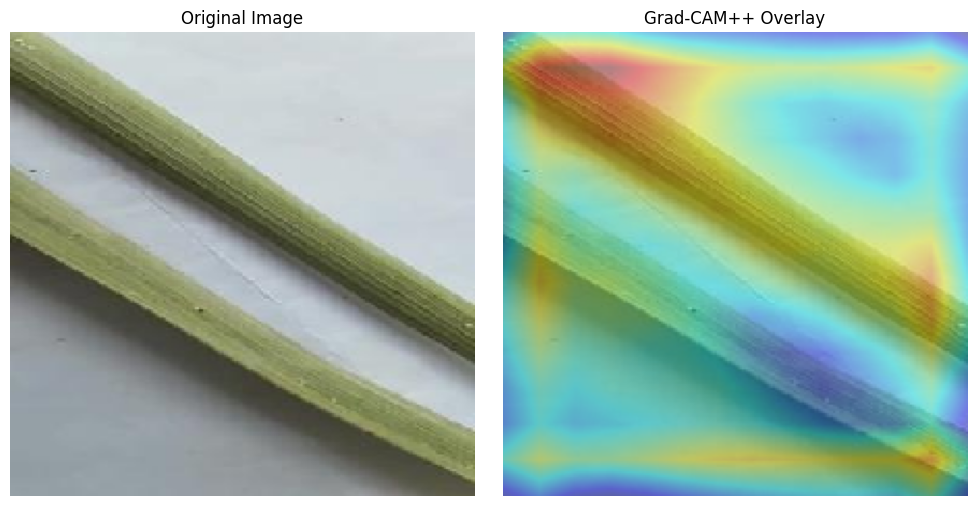

In [ ]:
overlayed_image = overlay_heatmap(img_array, heatmap)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_array)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Grad-CAM++ Overlay")
plt.imshow(overlayed_image)
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
pip install shap

/usr/local/lib/python3.11/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(2, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(4, 224, 224, 3))']



SHAP explanation for class: Healthy


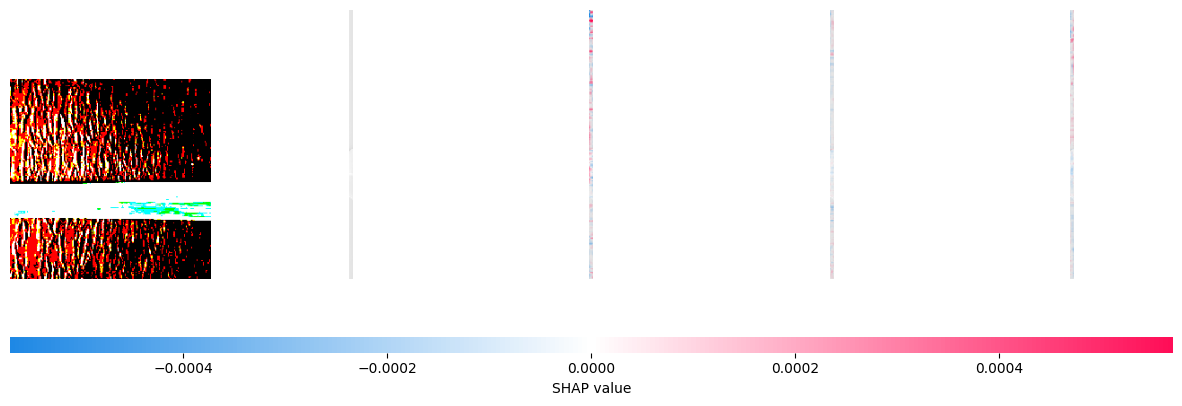


SHAP explanation for class: Stage1


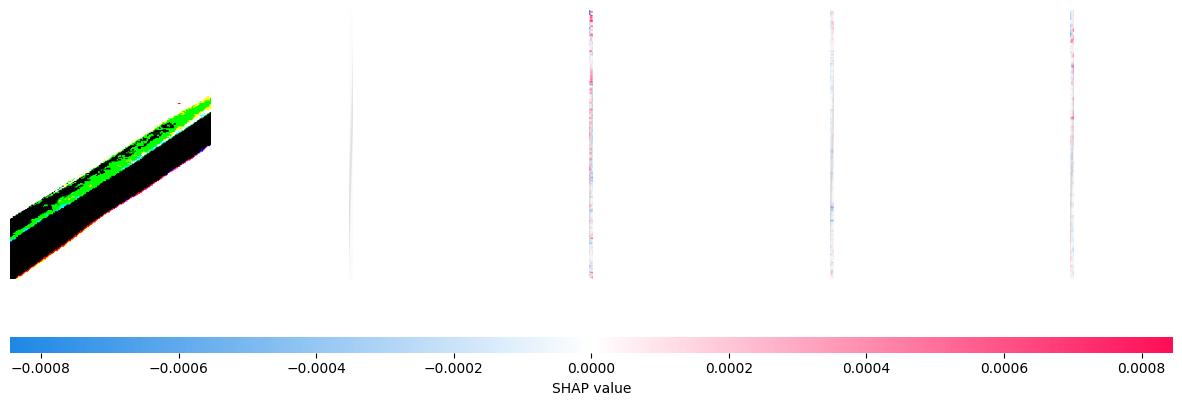


SHAP explanation for class: Stage2


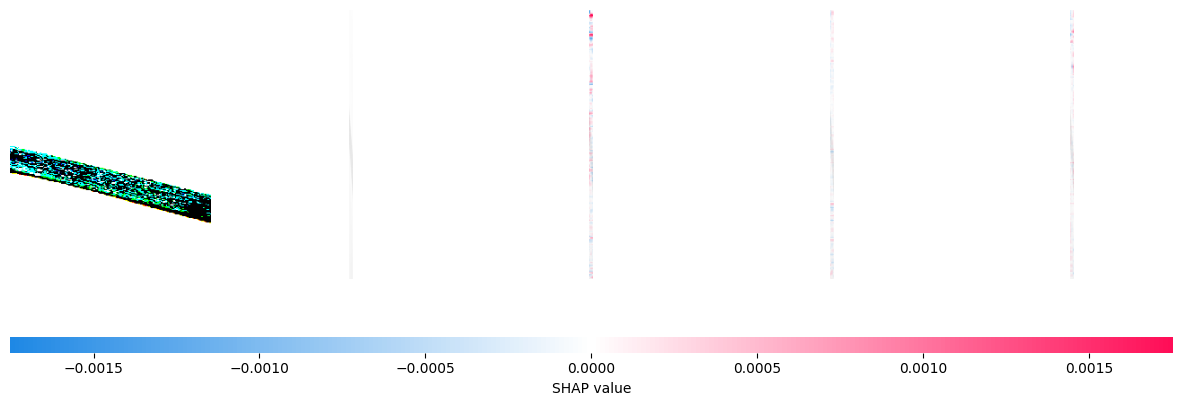


SHAP explanation for class: Stage3


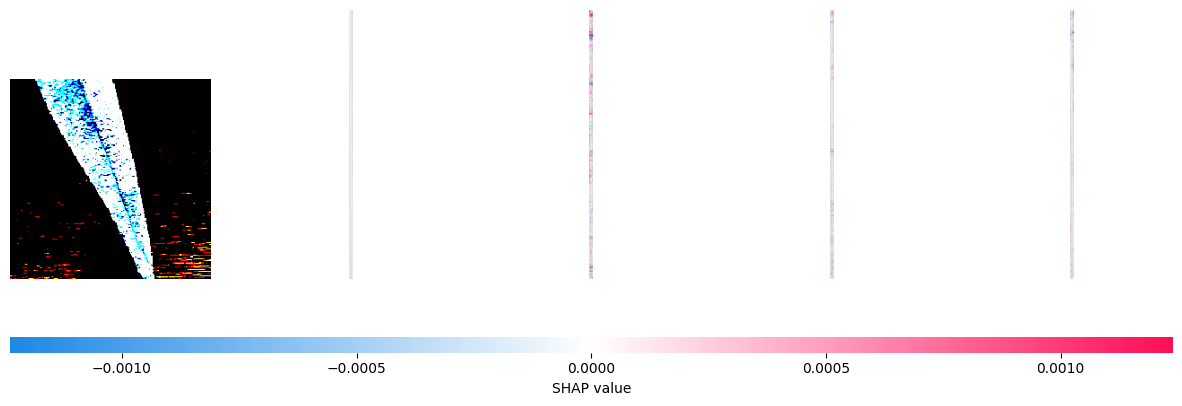

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
import os

# Define image size and class folders
img_size = (224, 224)
base_test_dir = '/content/drive/MyDrive/Final_Data2/test'
class_names = ['Healthy', 'Stage1', 'Stage2', 'Stage3']

# Function to load and preprocess image
def load_and_preprocess_image(path):
    img = load_img(path, target_size=img_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Load one image from each class
images = []
image_paths = []

for class_name in class_names:
    class_folder = os.path.join(base_test_dir, class_name)
    image_files = [f for f in os.listdir(class_folder) if f.lower().endswith(('.jpg', '.png'))]
    if image_files:
        selected_path = os.path.join(class_folder, image_files[0])
        image_paths.append(selected_path)
        img_array = load_and_preprocess_image(selected_path)
        images.append(img_array)

# Convert to numpy array
images_np = np.array(images)

# Make a SHAP explainer (DeepExplainer for Keras model)
background = images_np[:1]  # using 1 image as background
explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(images_np)

# Plot SHAP values
for i in range(len(images_np)):
    print(f"\nSHAP explanation for class: {class_names[i]}")
    shap.image_plot([shap_values[c][i:i+1] for c in range(len(shap_values))],
                    images_np[i:i+1])


In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=783fff693dcb1f4e8677581991521accb7ca14c881fb629d12c7a14b26998e01
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━

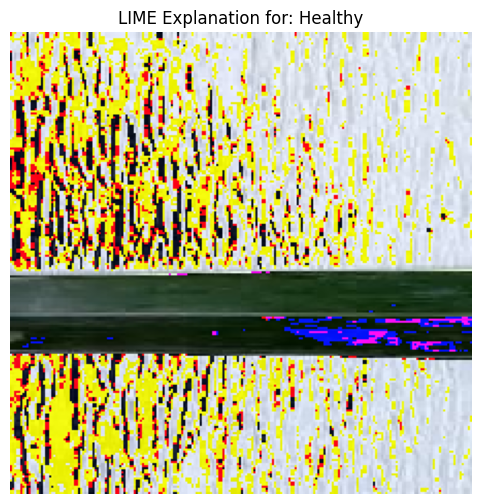

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

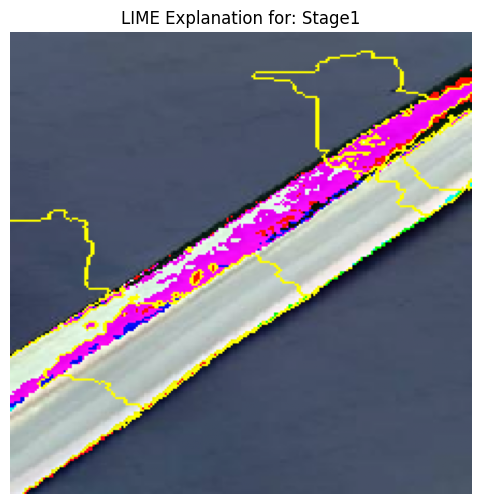

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

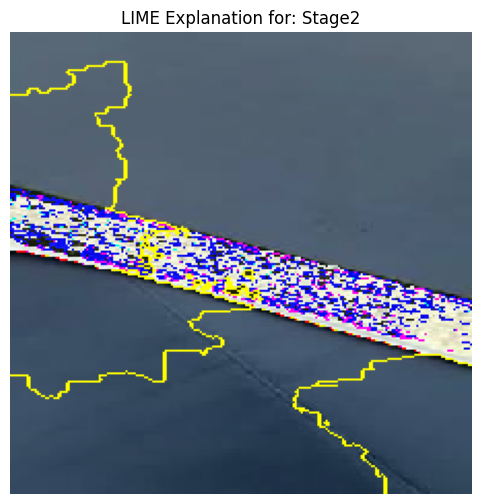

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

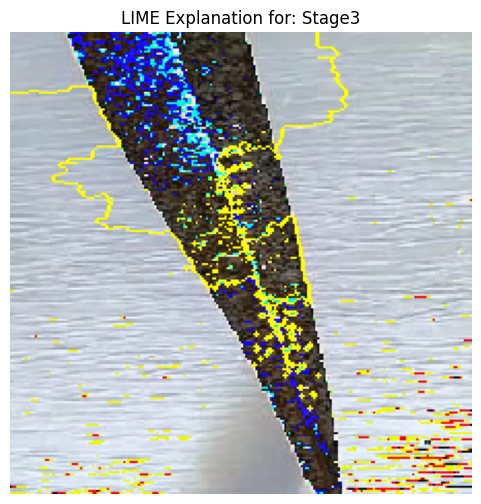

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from lime import lime_image
from skimage.segmentation import mark_boundaries
import os

# Your model (make sure it's loaded)
# model = load_model('path_to_your_model.h5')

# Define class labels and image directory
class_names = ['Healthy', 'Stage1', 'Stage2', 'Stage3']
base_test_dir = '/content/drive/MyDrive/Final_Data2/test'
img_size = (224, 224)

# Preprocessing function for LIME
def preprocess_image(img_path):
    img = load_img(img_path, target_size=img_size)
    img_array = img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    return preprocess_input(img_batch), img_array.astype('uint8')

# Prediction function for LIME
def predict_fn(images):
    images = np.array([preprocess_input(img) for img in images])
    return model.predict(images)

# Loop through one image from each class
for class_name in class_names:
    folder_path = os.path.join(base_test_dir, class_name)
    img_files = [f for f in os.listdir(folder_path) if f.endswith('.jpg') or f.endswith('.png')]

    if not img_files:
        continue

    img_path = os.path.join(folder_path, img_files[0])
    preprocessed_img, original_img = preprocess_image(img_path)

    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(original_img,
                                             predict_fn,
                                             top_labels=4,
                                             hide_color=0,
                                             num_samples=1000)

    # Get explanation for the top predicted class
    temp, mask = explanation.get_image_and_mask(
        label=explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    # Plot the result
    plt.figure(figsize=(6, 6))
    plt.title(f'LIME Explanation for: {class_name}')
    plt.imshow(mark_boundaries(temp, mask))
    plt.axis('off')
    plt.show()
